In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.table import Table
import seaborn as sns
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [20]:
# Load sample financial data
df = pd.read_csv('MSTR_2024.csv')

In [22]:
#Keep Date separate
df['Date'] = pd.to_datetime(df['Date'])
dfDate = df['Date']

#Strip Column spaces, modify date string etc.
df.columns = df.columns.str.strip()

#Eliminate Stock Split rows and any other NANs.
rowIndexToDrop = df[df.isnull().any(axis=1)]
df.iloc[rowIndexToDrop.index]
df = df.drop(rowIndexToDrop.index)
df = df.reset_index(drop=True)
# Make sure they're gone.
df[df.isnull().any(axis=1)]

#Convert text $ values to numeric for calculations. The r before the \$ indicates it's a raw string to avoid the escape \ character.
df['Open'] = df['Open'].replace({r'\$': '', ',': ''}, regex=True)
df['High'] = df['High'].replace({r'\$': '', ',': ''}, regex=True)
df['Low'] = df['Low'].replace({r'\$': '', ',': ''}, regex=True)
df['Close'] = df['Close'].replace({r'\$': '', ',': ''}, regex=True)
df['Adj Close'] = df['Adj Close'].replace({r'\$': '', ',': ''}, regex=True)
df['Volume'] = df['Volume'].replace({r'\$': '', ',': ''}, regex=True)
df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']] = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].apply(pd.to_numeric)
df = df[['Close','Open','High','Low','Adj Close','Volume']]

# Forward-fill missing values
df.fillna(method='ffill', inplace=True)

# Convert non-numeric data fields.
df = df.apply(pd.to_numeric, errors='coerce')
df['Date'] = dfDate
df=df.sort_values(by='Date', ascending=True)

### Chart Patterns

In [25]:
# Convert prices into boxes
def generate_pnf(data, box_size, reversal):
    columns = []
    curr_col = {'type': None, 'boxes': [], 'date': []}
    
    for i in range(1, len(data)):
        prev_price = data['Close'].iloc[i - 1]
        curr_price = data['Close'].iloc[i]
        move = (curr_price - prev_price) / box_size
        direction = 'X' if move > 0 else 'O'

        if curr_col['type'] is None:
            curr_col['type'] = direction
            curr_col['boxes'].append(int(curr_price // box_size))
            curr_col['date'].append(data['Date'].iloc[i])
        
        else:
            price_level = int(curr_price // box_size)
            last_price_level = curr_col['boxes'][-1]
            price_diff = price_level - last_price_level

            if curr_col['type'] == direction:
                # Continue current column
                if (curr_col['type'] == 'X' and price_level > last_price_level) or \
                   (curr_col['type'] == 'O' and price_level < last_price_level):
                    curr_col['boxes'].append(price_level)
                    curr_col['date'].append(data['Date'].iloc[i])

            else:
                # Check if reversal
                if abs(price_diff) >= reversal:
                    columns.append(curr_col)
                    curr_col = {'type': direction, 'boxes': [price_level], 'date': [data['Date'].iloc[i]]}

    columns.append(curr_col)
    return columns

# Quick visualization
def plot_pnf(columns):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, col in enumerate(columns):
        if col['type'] == 'X':
            marker = 'X'
        else:
            marker = 'o'
        y_vals = col['boxes']
        x_vals = [i] * len(y_vals)
        ax.scatter(x_vals, y_vals, marker=marker, label=col['type'])
    ax.invert_yaxis()
    plt.title("Point & Figure Chart")
    plt.show()

In [27]:
def detect_pnf_patterns(columns):
    patterns = []

    for i in range(2, len(columns)):
        c0 = columns[i - 2]  # Oldest
        c1 = columns[i - 1]
        c2 = columns[i]      # Most recent

        # Double Top: X column breaks above previous X column high
        if c0['type'] == 'X' and c2['type'] == 'X':
            if max(c2['boxes']) > max(c0['boxes']) and c1['type'] == 'O':
                patterns.append({
                    'pattern': 'Double Top',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': max(c2['boxes'])
                })

        # Double Bottom: O column breaks below previous O column low
        if c0['type'] == 'O' and c2['type'] == 'O':
            if min(c2['boxes']) < min(c0['boxes']) and c1['type'] == 'X':
                patterns.append({
                    'pattern': 'Double Bottom',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': min(c2['boxes'])
                })

        # Triple Top: Two previous tops at same level, and a breakout above
        if (c0['type'], c1['type'], c2['type']) == ('X', 'O', 'X'):
            if max(c0['boxes']) == max(c2['boxes']) and max(c2['boxes']) > max(c1['boxes']):
                patterns.append({
                    'pattern': 'Triple Top',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': max(c2['boxes'])
                })

        # Triple Bottom: Two previous bottoms at same level, and a breakdown below
        if (c0['type'], c1['type'], c2['type']) == ('O', 'X', 'O'):
            if min(c0['boxes']) == min(c2['boxes']) and min(c2['boxes']) < min(c1['boxes']):
                patterns.append({
                    'pattern': 'Triple Bottom',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': min(c2['boxes'])
                })

        # Bullish Signal: higher high after a higher low
        if (c0['type'], c1['type'], c2['type']) == ('O', 'X', 'O'):
            if min(c2['boxes']) > min(c0['boxes']):
                patterns.append({
                    'pattern': 'Bullish Signal',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': min(c2['boxes'])
                })

        # Bearish Signal: lower low after a lower high
        if (c0['type'], c1['type'], c2['type']) == ('X', 'O', 'X'):
            if max(c2['boxes']) < max(c0['boxes']):
                patterns.append({
                    'pattern': 'Bearish Signal',
                    'column': i,
                    'date': c2['date'][-1],
                    'price_level': max(c2['boxes'])
                })

    return patterns


In [29]:
def detect_advanced_pnf_patterns(columns):
    patterns = []

    for i in range(3, len(columns)):
        c0, c1, c2, c3 = columns[i - 3:i + 1]

        # Bullish Catapult: Double Top followed by a higher low and breakout
        if (c0['type'], c1['type'], c2['type'], c3['type']) == ('X', 'O', 'X', 'O'):
            if max(c0['boxes']) == max(c2['boxes']) and min(c1['boxes']) > min(c3['boxes']):
                patterns.append({
                    'pattern': 'Bullish Catapult',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': min(c3['boxes'])
                })

        # Bearish Catapult: Double Bottom followed by a lower high and breakdown
        if (c0['type'], c1['type'], c2['type'], c3['type']) == ('O', 'X', 'O', 'X'):
            if min(c0['boxes']) == min(c2['boxes']) and max(c1['boxes']) < max(c3['boxes']):
                patterns.append({
                    'pattern': 'Bearish Catapult',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': max(c3['boxes'])
                })

        # Bullish Triangle: X-O-X-O sequence narrowing (higher lows, lower highs)
        if (c0['type'], c1['type'], c2['type'], c3['type']) == ('X', 'O', 'X', 'O'):
            if (max(c2['boxes']) < max(c0['boxes']) and 
                min(c3['boxes']) > min(c1['boxes'])):
                patterns.append({
                    'pattern': 'Bullish Triangle',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': min(c3['boxes'])
                })

        # Bearish Triangle: O-X-O-X narrowing (lower highs, higher lows)
        if (c0['type'], c1['type'], c2['type'], c3['type']) == ('O', 'X', 'O', 'X'):
            if (min(c2['boxes']) > min(c0['boxes']) and 
                max(c3['boxes']) < max(c1['boxes'])):
                patterns.append({
                    'pattern': 'Bearish Triangle',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': max(c3['boxes'])
                })

        # Spread Triple Top: 3 tops spread out, break above all 3
        if c0['type'] == c2['type'] == c3['type'] == 'X' and c1['type'] == 'O':
            if max(c0['boxes']) == max(c2['boxes']) and max(c3['boxes']) > max(c0['boxes']):
                patterns.append({
                    'pattern': 'Spread Triple Top',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': max(c3['boxes'])
                })

        # Spread Triple Bottom: 3 bottoms spread out, break below all 3
        if c0['type'] == c2['type'] == c3['type'] == 'O' and c1['type'] == 'X':
            if min(c0['boxes']) == min(c2['boxes']) and min(c3['boxes']) < min(c0['boxes']):
                patterns.append({
                    'pattern': 'Spread Triple Bottom',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': min(c3['boxes'])
                })

        # Broadening Formation: lower lows and higher highs
        highs = [max(c['boxes']) for c in [c0, c1, c2, c3] if c['type'] == 'X']
        lows  = [min(c['boxes']) for c in [c0, c1, c2, c3] if c['type'] == 'O']
        if len(highs) >= 2 and len(lows) >= 2:
            if highs[-1] > highs[-2] and lows[-1] < lows[-2]:
                patterns.append({
                    'pattern': 'Broadening Formation',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': highs[-1]
                })

        # Bullish Signal Reversed: failed double top, price reverses down
        if c0['type'] == 'X' and c1['type'] == 'O' and c2['type'] == 'X' and c3['type'] == 'O':
            if max(c2['boxes']) == max(c0['boxes']) and min(c3['boxes']) < min(c1['boxes']):
                patterns.append({
                    'pattern': 'Bullish Signal Reversed',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': min(c3['boxes'])
                })

        # Bearish Signal Reversed: failed double bottom, price reverses up
        if c0['type'] == 'O' and c1['type'] == 'X' and c2['type'] == 'O' and c3['type'] == 'X':
            if min(c2['boxes']) == min(c0['boxes']) and max(c3['boxes']) > max(c1['boxes']):
                patterns.append({
                    'pattern': 'Bearish Signal Reversed',
                    'column': i,
                    'date': c3['date'][-1],
                    'price_level': max(c3['boxes'])
                })

    return patterns


### Trend Lines
1. Bullish and Bearish Support
2. Bullish and Bearish Resistance

In [32]:
def generate_trend_lines_with_channels(columns):
    bullish_support = []
    bearish_resistance = []
    bullish_resistance = []
    bearish_support = []

    for i, col in enumerate(columns):
        if col['type'] == 'X':
            anchor_y = min(col['boxes'])
            anchor_x = i
            support_line = []
            resistance_line = []

            for j in range(i, len(columns)):
                x = j
                y_support = anchor_y + (j - anchor_x)  # 45° up
                y_resistance = anchor_y + (j - anchor_x) + 3  # channel line above

                support_line.append((x, y_support))
                resistance_line.append((x, y_resistance))

                if columns[j]['type'] == 'O' and min(columns[j]['boxes']) < y_support:
                    break

            bullish_support.append({
                'type': 'Bullish Support Line',
                'start_column': i,
                'line': support_line
            })

            bullish_resistance.append({
                'type': 'Bullish Resistance Line',
                'start_column': i,
                'line': resistance_line
            })

        elif col['type'] == 'O':
            anchor_y = max(col['boxes'])
            anchor_x = i
            resistance_line = []
            support_line = []

            for j in range(i, len(columns)):
                x = j
                y_resistance = anchor_y - (j - anchor_x)  # 45° down
                y_support = anchor_y - (j - anchor_x) - 3  # channel line below

                resistance_line.append((x, y_resistance))
                support_line.append((x, y_support))

                if columns[j]['type'] == 'X' and max(columns[j]['boxes']) > y_resistance:
                    break

            bearish_resistance.append({
                'type': 'Bearish Resistance Line',
                'start_column': i,
                'line': resistance_line
            })

            bearish_support.append({
                'type': 'Bearish Support Line',
                'start_column': i,
                'line': support_line
            })

    return bullish_support, bearish_resistance, bullish_resistance, bearish_support


### Price Objectives
1. Horizontal count
Strict Triple Top: All three tops have exactly the same price (classic definition).
Fuzzy Triple Top: The three tops are within ±1 box size.
Progressive Highs: Three consecutive X-columns with increasing or same highs, signaling bullish momentum.
Breakout After Double Top: A double top followed by a higher breakout column.

2. Vertical count

In [35]:
def calculate_horizontal_count_equaltripletop(columns, box_size=1, reversal=3, multiplier=1):
    objectives = []

    for i in range(len(columns) - 2):
        c1, c2, c3 = columns[i], columns[i+1], columns[i+2]

        # Look for triple top breakout
        if c1['type'] == 'X' and c3['type'] == 'X':
            if max(c1['boxes']) == max(c2['boxes']) == max(c3['boxes']):
                base_columns = 3  # could scan for wider base
                breakout_price = max(c3['boxes'])
                target = breakout_price + (base_columns * box_size * reversal * multiplier)

                objectives.append({
                    'type': 'Horizontal Count (Triple Top)',
                    'start_column': i,
                    'breakout_price': breakout_price,
                    'price_objective': target
                })

        # Triple bottom breakdown
        if c1['type'] == 'O' and c3['type'] == 'O':
            if min(c1['boxes']) == min(c2['boxes']) == min(c3['boxes']):
                base_columns = 3
                breakout_price = min(c3['boxes'])
                target = breakout_price - (base_columns * box_size * reversal * multiplier)

                objectives.append({
                    'type': 'Horizontal Count (Triple Bottom)',
                    'start_column': i,
                    'breakout_price': breakout_price,
                    'price_objective': target
                })

    return objectives

def calculate_horizontal_count(columns, box_size=1, reversal=3, multiplier=1):
    objectives = []

    for i in range(6, len(columns)):
        c = columns[i]
        if c['type'] != 'X':
            continue

        highs = [max(col['boxes']) for col in columns[i-6:i] if col['type'] == 'X']
        prev_cols = columns[i-6:i]

        # Strict Triple Top
        if len(highs) >= 3 and highs[-1] == highs[-2] == highs[-3]:
            breakout_price = highs[-1]
            target = breakout_price + (3 * box_size * reversal * multiplier)
            objectives.append({
                'index': i,
                'pattern': 'Strict Triple Top',
                'breakout_price': breakout_price,
                'target': target,
                'date': c['date'][-1]
            })
            continue

        # Fuzzy Triple Top (±box_size)
        if (len(highs) >= 3 and
            abs(highs[-1] - highs[-2]) <= box_size and
            abs(highs[-2] - highs[-3]) <= box_size):
            breakout_price = highs[-1]
            target = breakout_price + (3 * box_size * reversal * multiplier)
            objectives.append({
                'index': i,
                'pattern': 'Fuzzy Triple Top',
                'breakout_price': breakout_price,
                'target': target,
                'date': c['date'][-1]
            })
            continue

        # Progressive Highs
        if len(highs) >= 3 and highs[-3] < highs[-2] <= highs[-1]:
            breakout_price = highs[-1]
            target = breakout_price + (3 * box_size * reversal * multiplier)
            objectives.append({
                'index': i,
                'pattern': 'Progressive Highs',
                'breakout_price': breakout_price,
                'target': target,
                'date': c['date'][-1]
            })
            continue

        # Double Top then Breakout
        if len(highs) >= 3 and highs[-3] == highs[-2] and highs[-1] > highs[-2]:
            breakout_price = highs[-1]
            target = breakout_price + (3 * box_size * reversal * multiplier)
            objectives.append({
                'index': i,
                'pattern': 'Double Top then Breakout',
                'breakout_price': breakout_price,
                'target': target,
                'date': c['date'][-1]
            })

    return objectives


def calculate_vertical_count(columns, box_size=1, reversal=3):
    objectives = []

    for i, col in enumerate(columns):
        if col['type'] == 'X':
            height = len(col['boxes'])
            breakout_price = max(col['boxes'])
            target = breakout_price + (height * box_size * reversal)
            objectives.append({
                'type': 'Vertical Count (Bullish)',
                'start_column': i,
                'breakout_price': breakout_price,
                'price_objective': target
            })

        elif col['type'] == 'O':
            height = len(col['boxes'])
            breakout_price = min(col['boxes'])
            target = breakout_price - (height * box_size * reversal)
            objectives.append({
                'type': 'Vertical Count (Bearish)',
                'start_column': i,
                'breakout_price': breakout_price,
                'price_objective': target
            })

    return objectives


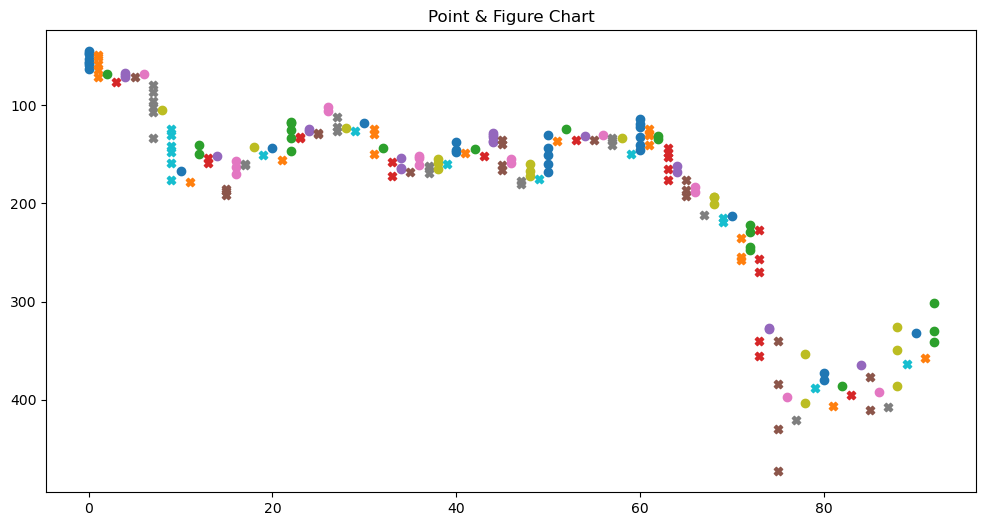

In [37]:
# Define box size and reversal (adjust to your settings)
BOX_SIZE = 1
REVERSAL = 3

pnf_columns = generate_pnf(df, box_size=BOX_SIZE, reversal=REVERSAL)
plot_pnf(pnf_columns)
# Generate Patterns
basic_patterns = detect_pnf_patterns(pnf_columns)
advanced_patterns = detect_advanced_pnf_patterns(pnf_columns)
all_patterns = basic_patterns + advanced_patterns

# Detect trend lines (optional)
bullish_support, bearish_resistance, bullish_resistance, bearish_support = generate_trend_lines_with_channels(pnf_columns)

# Detect price objectives
horizontal_objectives = calculate_horizontal_count(pnf_columns, box_size=BOX_SIZE, reversal=REVERSAL)
vertical_objectives = calculate_vertical_count(pnf_columns, box_size=BOX_SIZE, reversal=REVERSAL)
all_objectives = horizontal_objectives + vertical_objectives

In [136]:
pnf_columns[:10]

[{'type': 'X',
  'boxes': [21, 24, 25, 28],
  'date': [Timestamp('2023-01-13 00:00:00'),
   Timestamp('2023-01-20 00:00:00'),
   Timestamp('2023-01-27 00:00:00'),
   Timestamp('2023-02-03 00:00:00')]},
 {'type': 'O', 'boxes': [24], 'date': [Timestamp('2023-02-10 00:00:00')]},
 {'type': 'X', 'boxes': [29], 'date': [Timestamp('2023-02-17 00:00:00')]},
 {'type': 'O',
  'boxes': [25, 24, 19],
  'date': [Timestamp('2023-02-24 00:00:00'),
   Timestamp('2023-03-03 00:00:00'),
   Timestamp('2023-03-10 00:00:00')]},
 {'type': 'X',
  'boxes': [26, 29, 33],
  'date': [Timestamp('2023-03-17 00:00:00'),
   Timestamp('2023-03-31 00:00:00'),
   Timestamp('2023-04-14 00:00:00')]},
 {'type': 'O', 'boxes': [29], 'date': [Timestamp('2023-04-21 00:00:00')]},
 {'type': 'X', 'boxes': [32], 'date': [Timestamp('2023-04-28 00:00:00')]},
 {'type': 'O', 'boxes': [27], 'date': [Timestamp('2023-05-12 00:00:00')]},
 {'type': 'X',
  'boxes': [30, 32, 34, 38, 45],
  'date': [Timestamp('2023-06-02 00:00:00'),
   Times

In [137]:
def plot_pnf_chart(columns, column_width=1.2):
    """
    Plots an enhanced Point & Figure chart using Plotly.

    Parameters:
    - columns: List of dicts with column type and boxes
    - column_width: Horizontal spacing between columns (float)

    Returns:
    - fig: Plotly Figure object
    """
    fig = go.Figure()

    for i, col in enumerate(columns):
        x_pos = i * column_width
        y_vals = col['boxes']
        color = 'green' if col['type'] == 'X' else 'red'
        symbol = 'X' if col['type'] == 'X' else 'O'

        for j, y in enumerate(y_vals):
            fig.add_trace(go.Scatter(
                x=[x_pos],
                y=[y],
                mode='text',
                text=[symbol],
                textfont=dict(size=9, color=color, family='Courier New'),
                showlegend=False
            ))

    fig.update_layout(
        title='Point & Figure Chart',
        width=1200,
        height=800,
        xaxis=dict(
            title='Column Index',
            showgrid=True,
            zeroline=False,
            tickmode='linear',
            tick0=0,
            dtick=column_width,
        ),
        yaxis=dict(
            title='Price',
            showgrid=True,
            tickformat='.2f'
        ),
        plot_bgcolor='white',
        template='plotly_white'
    )

    return fig

In [86]:
# Create chart
fig_pnfchart = plot_pnf_chart(pnf_columns)
fig_pnfchart.show()

In [87]:
# Prepare Plotly figure with 3 vertically stacked subplots
fig_pnf_allpatterns = make_subplots(rows=3, cols=1, shared_xaxes=True, shared_yaxes=True,
                    vertical_spacing=0.05,
                    subplot_titles=("P&F Chart (Literal X and O)",
                                    "Pattern Dots",
                                    "Signals"))

# --- Chart 1: Literal X and O ---
for i, col in enumerate(pnf_columns):
    for y in col['boxes']:
        fig_pnf_allpatterns.add_trace(
            go.Scatter(
                x=[i],
                y=[y],
                text='X' if col['type'] == 'X' else 'O',
                mode='text',
                textfont=dict(color='green' if col['type'] == 'X' else 'red', size=12),
                name='X' if col['type'] == 'X' else 'O',
                showlegend=False
            ),
            row=1, col=1
        )

# --- Chart 2: Pattern Dots with legend ---
unique_patterns = list({p['pattern'] for p in all_patterns})
palette = [
    "black", "gray", "lightblue", "blue", "darkblue",
    "lightgreen", "green", "darkgreen", "lightcoral", "darkred"
]
pattern_colors = {pat: palette[i % len(palette)] for i, pat in enumerate(unique_patterns)}

for p in all_patterns:
    fig_pnf_allpatterns.add_trace(
        go.Scatter(
            x=[p['column']],
            y=[p['price_level']],
            mode='markers',
            marker=dict(color=pattern_colors[p['pattern']], size=5),
            name=p['pattern'],
            showlegend=False
        ),
        row=2, col=1
    )

# Add manual pattern legend
for pat, col in pattern_colors.items():
    fig_pnf_allpatterns.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode='markers',
            marker=dict(size=5, color=col),
            name=pat
        )
    )

# --- Chart 3: Signal Dots ---
for i, col in enumerate(pnf_columns):
    if col['type'] == 'X':
        for y in col['boxes']:
            fig_pnf_allpatterns.add_trace(
                go.Scatter(
                    x=[i],
                    y=[y],
                    mode='markers',
                    marker=dict(color='lightgreen', size=5),
                    text=[f"${y}"],
                    textposition="middle right",
                    showlegend=False
                ),
                row=3, col=1
            )

for p in all_patterns:
    if "bullish" in p['pattern'].lower():
        fig_pnf_allpatterns.add_trace(
            go.Scatter(
                x=[p['column']],
                y=[p['price_level']],
                mode='markers',
                marker=dict(color='darkgreen', size=5),
                text=[f"${p['price_level']}"],
                textposition="middle right",
                showlegend=False
            ),
            row=3, col=1
        )

# Update layout and axes
fig_pnf_allpatterns.update_layout(
    width=1200,
    height=1200,
    title_text="Point and Figure Chart - Plotly Edition",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,  # push below chart
        xanchor="center",
        x=0.5
    )
)
fig_pnf_allpatterns.update_yaxes(dtick=50)

fig_pnf_allpatterns.show()


In [88]:
def plot_all_trend_lines(trendline_sets):
    """
    Plots all trend lines in a separate figure (fig_trendlines).

    Parameters:
    - trendline_sets: list of trendline lists

    Returns:
    - fig_trendlines: Plotly Figure object
    """
    fig = go.Figure()

    # Map more descriptive types to colors
    type_colors = {
        'Bullish Support Line': 'green',
        'Bearish Resistance Line': 'red',
        'Bullish Resistance Line': 'blue',
        'Bearish Support Line': 'orange'
    }

    for trendlines in trendline_sets:
        for line_data in trendlines:
            line = line_data['line']
            x_vals = [pt[0] for pt in line]
            y_vals = [pt[1] for pt in line]
            color = type_colors.get(line_data['type'], 'gray')

            fig.add_trace(go.Scatter(
                x=x_vals,
                y=y_vals,
                mode='lines',
                line=dict(color=color, width=2, dash='dash'),
                showlegend=False
            ))

    fig.update_layout(
        width=1200,
        height=800,
        title='Trendlines (Separate View)',
        xaxis=dict(showgrid=True, showticklabels=False),
        yaxis=dict(autorange='reversed', showgrid=True, showticklabels=False),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=10, r=10, t=40, b=10),
    )

    return fig


In [89]:
# Overlay trend lines
fig_trendlines = plot_all_trend_lines([bullish_support, bearish_resistance, bullish_resistance, bearish_support])
fig_trendlines.show()

In [90]:
def plot_all_price_objectives(all_objectives):
    """
    Plots all price objectives (horizontal and vertical) from a list of objective dicts.

    Parameters:
    - all_objectives: list of dicts with keys:
        - 'type': e.g., 'Vertical Count (Bullish)' or 'Horizontal Count'
        - 'start_column': x-axis position
        - 'breakout_price': price at breakout
        - 'price_objective': target price

    Returns:
    - Plotly figure
    """
    fig = go.Figure()

    # Match colors by type keywords
    def get_color(objective_type):
        if "Vertical" in objective_type:
            return "purple"
        elif "Horizontal" in objective_type:
            return "teal"
        else:
            return "gray"

    for obj in all_objectives:
        if not all(k in obj for k in ['type', 'start_column', 'breakout_price', 'price_objective']):
            continue

        obj_type = obj['type']
        x = obj['start_column']
        y1 = obj['breakout_price']
        y2 = obj['price_objective']
        color = get_color(obj_type)

        if y1 is None or y2 is None:
            continue

        if "Vertical" in obj_type:
            fig.add_trace(go.Scatter(
                x=[x, x],
                y=[y1, y2],
                mode='lines+markers',
                marker=dict(size=6, color=color),
                line=dict(color=color, width=2, dash='dot'),
                showlegend=False
            ))

        elif "Horizontal" in obj_type:
            fig.add_trace(go.Scatter(
                x=[x - 0.5, x + 0.5],
                y=[y2, y2],
                mode='lines+markers',
                marker=dict(size=6, color=color),
                line=dict(color=color, width=2, dash='dash'),
                showlegend=False
            ))

    fig.update_layout(
        width=1200,
        height=800,
        title='Price Objectives (Breakout and Targets)',
        xaxis=dict(showgrid=True, showticklabels=True),
        yaxis=dict(showgrid=True, showticklabels=True),
        plot_bgcolor='white',
        paper_bgcolor='white',
        margin=dict(l=20, r=20, t=40, b=20),
    )

    return fig

In [91]:
# Overlay price objectives
fig_priceobjectives = plot_all_price_objectives(all_objectives)
fig_priceobjectives.show()

### Trade Tactics
Component || Role in Strategy
1. Establishing the Trade || Entry rules (based on patterns + confirmation)
2. Profitability Tables || Historical win rate / R-multiples tracking
3. Pullbacks || Entry on pullback after breakout or failed reversal
4. Stop Loss Orders || Rule-based exits when trend breaks or reversal patterns appear
5. Taking Profits || Objective-based exits (horizontal/vertical targets hit)
6. Volume || Confirmation filter (if volume data is available)

In [92]:
# === TRADING SIGNAL MODULE INTEGRATION WITH TREND LINES ===

def generate_trade_signals(columns, price_objectives, trend_lines, volume=None):
    signals = []
    trade_log = []
    active_trade = None

    # Unpack trend lines for clarity
    bullish_support, bearish_resistance, bullish_resistance, bearish_support = trend_lines

    for i, col in enumerate(columns):
        # === ENTRY: Pattern Breakout + Trend Filter ===
        if active_trade is None:
            if should_enter_trade(columns, i, volume):
                # Use trend confirmation
                if i < len(bullish_support) and max(col['boxes']) > bullish_support[i]:
                    entry_price = max(col['boxes'])
                    signals.append({
                        'type': 'Buy',
                        'column': i,
                        'price': entry_price,
                        'reason': 'Pattern Breakout with Bullish Support'
                    })
                    active_trade = {
                        'side': 'long',
                        'entry_price': entry_price,
                        'entry_column': i
                    }
                    continue

        # === PULLBACK ENTRY: Confirm Support Hold ===
        if active_trade is None and i > 0:
            if detect_pullback_entry(columns, i, bullish_support):
                entry_price = max(col['boxes'])
                signals.append({
                    'type': 'Buy',
                    'column': i,
                    'price': entry_price,
                    'reason': 'Pullback Entry on Bullish Support'
                })
                active_trade = {
                    'side': 'long',
                    'entry_price': entry_price,
                    'entry_column': i
                }
                continue

        # === EXIT (PROFIT TARGET) ===
        if active_trade:
            hit, target_price = profit_hit(active_trade, col, price_objectives)
            if hit:
                signals.append({
                    'type': 'Sell',
                    'column': i,
                    'price': target_price,
                    'reason': 'Profit Target Hit'
                })
                log_trade(trade_log, active_trade['entry_price'], target_price, 'Profit Target Hit', active_trade['entry_column'], i)
                active_trade = None
                continue

            # === STOP LOSS ===
            if stop_hit(columns, active_trade, i):
                exit_price = min(col['boxes'])
                signals.append({
                    'type': 'Sell',
                    'column': i,
                    'price': exit_price,
                    'reason': 'Stop Loss Hit'
                })
                log_trade(trade_log, active_trade['entry_price'], exit_price, 'Stop Loss Hit', active_trade['entry_column'], i)
                active_trade = None
                continue

    return signals, trade_log

# === HELPERS ===

def should_enter_trade(columns, i, volume=None):
    if i < 1:
        return False
    col = columns[i]
    breakout = detect_triple_top(columns, i) or detect_double_top(columns, i)
    volume_ok = True
    if volume is not None and i > 0:
        volume_ok = volume[i] > volume[i - 1]
    return breakout and volume_ok

def detect_pullback_entry(columns, i, bullish_support):
    if i < 1:
        return False
    col = columns[i]
    prev_col = columns[i - 1] 
    # Find the correct support level from bullish_support
    support = None
    for line in bullish_support:
        if line['start_column'] <= i:  # We are only interested in support lines up to the current column
            support = line['line'][-1][1]  # Use the last price in the line, e.g., the second value of the tuple (column, price)
            break
    if support is None:
        return False
    # Pullback entry logic: check if current box price is greater than or equal to the support level
    if col['type'] == 'O' and prev_col['type'] == 'X':  # Assuming 'O' and 'X' signify different box types
        return min(col['boxes']) >= support  # Compare the minimum value of the current column to the support level
    return False

def stop_hit(columns, active_trade, i):
    col = columns[i]
    if active_trade['side'] == 'long':
        reversal_level = active_trade['entry_price'] - 3
        return col['boxes'][-1] < reversal_level
    return False

def profit_hit(active_trade, col, objectives):
    for obj in objectives:
        if obj.get('start_column') == active_trade['entry_column']:
            if active_trade['side'] == 'long' and col['boxes'][-1] >= obj['price_objective']:
                return True, obj['price_objective']
    return False, None

def log_trade(trade_log, entry_price, exit_price, reason, entry_column, exit_column):
    pnl = exit_price - entry_price
    trade_log.append({
        'entry': entry_price,
        'exit': exit_price,
        'pnl': pnl,
        'reason': reason,
        'bars_held': exit_column - entry_column
    })

def plot_trade_signals(fig, signals):
    for signal in signals:
        color = 'green' if signal['type'] == 'Buy' else 'red'
        fig.add_annotation(
            x=signal['column'],
            y=signal['price'],
            text=signal['type'],
            showarrow=True,
            arrowhead=1,
            ax=0,
            ay=-40,
            bgcolor=color,
            font=dict(color='white')
        )

def detect_triple_top(columns, i):
    if i < 2:
        return False
    try:
        top1 = max(columns[i-2]['boxes'])
        top2 = max(columns[i-1]['boxes'])
        top3 = max(columns[i]['boxes'])
        return top1 == top2 == top3
    except:
        return False

def detect_double_top(columns, i):
    if i < 1:
        return False
    try:
        top1 = max(columns[i-1]['boxes'])
        top2 = max(columns[i]['boxes'])
        return top1 == top2
    except:
        return False


In [93]:
# Usage after generating columns, objectives, and trend lines:
trend_lines = [bullish_support, bearish_resistance, bullish_resistance, bearish_support]
signals, trade_log = generate_trade_signals(pnf_columns, all_objectives, trend_lines)
fig_tradesignals = plot_pnf_chart(pnf_columns)
plot_trade_signals(fig_tradesignals, signals)
fig_tradesignals.show()

In [99]:
def count_patterns(patterns):
    pattern_names = [p['pattern'] for p in patterns]
    return Counter(pattern_names)

def simulate_strategy_original(patterns, price_series):
    positions = []
    in_trade = False
    entry_price = 0

    for pattern in patterns:
        if pattern['pattern'] in ['Bullish Signal', 'Triple Top'] and not in_trade:
            entry_price = pattern['price_level']
            entry_date = pattern['date']
            in_trade = True
            positions.append({'type': 'BUY', 'date': entry_date, 'price': entry_price})
        elif pattern['pattern'] in ['Bearish Signal', 'Double Top'] and in_trade:
            exit_price = pattern['price_level']
            exit_date = pattern['date']
            in_trade = False
            positions.append({'type': 'SELL', 'date': exit_date, 'price': exit_price})

    return positions

# Simulate strategy with risk management (stop-loss, take-profit)
def simulate_strategy(pnf_columns, patterns, df, initial_capital=10000, risk_per_trade=0.02, stop_loss=5, take_profit=10):
    positions = []
    capital = initial_capital
    in_trade = False
    entry_price = 0
    entry_date = None
    stop_loss_price = 0
    take_profit_price = 0
    position_size = 0
    
    for pattern in patterns:
        # Match the pattern date with df
        pattern_date = pd.to_datetime(pattern['date'], format='%m/%d/%Y')
        
        # Find the corresponding price from df for the given pattern date
        price_row = df[df['Date'] == pattern_date]
        
        if not price_row.empty:
            price = price_row['Close'].iloc[0]
        else:
            # If the pattern date does not exist in the DataFrame, skip
            continue
        
        if pattern['pattern'] in ['Bullish Signal', 'Triple Top'] and not in_trade:
            # Calculate position size based on risk per trade and stop-loss percentage
            position_size = (capital * risk_per_trade) / (stop_loss / 100)
            
            # Set stop-loss and take-profit prices
            stop_loss_price = price * (1 - stop_loss / 100)
            take_profit_price = price * (1 + take_profit / 100)
            
            # Entry point for a Bullish pattern
            entry_price = price
            entry_date = pattern['date']
            in_trade = True
            positions.append({'type': 'BUY', 'date': entry_date, 'price': entry_price, 'size': position_size})

        elif pattern['pattern'] in ['Bearish Signal', 'Double Top'] and in_trade:
            # Exit point for a Bearish pattern
            exit_price = price
            exit_date = pattern['date']
            in_trade = False
            positions.append({'type': 'SELL', 'date': exit_date, 'price': exit_price, 'size': position_size})

            # Update capital after closing the trade (profit/loss calculation)
            capital += (exit_price - entry_price) * position_size

        # Check if stop-loss or take-profit conditions are met during the trade
        if in_trade:
            if price <= stop_loss_price or price >= take_profit_price:
                # Exit if stop-loss or take-profit is triggered
                exit_price = price
                exit_date = pattern['date']
                in_trade = False
                positions.append({'type': 'SELL', 'date': exit_date, 'price': exit_price, 'size': position_size})
                capital += (exit_price - entry_price) * position_size

    return positions, capital

def aggregate_patterns_by_date(patterns):
    df = pd.DataFrame(patterns)
    return df.groupby('date').size()

In [100]:
pattern_counts = count_patterns(all_patterns)  # list from your P&F pattern logic
strategic_positions = simulate_strategy(pnf_columns, all_patterns, df, initial_capital=10000, risk_per_trade=0.02, stop_loss=5, take_profit=10)
aggregated = aggregate_patterns_by_date(all_patterns)

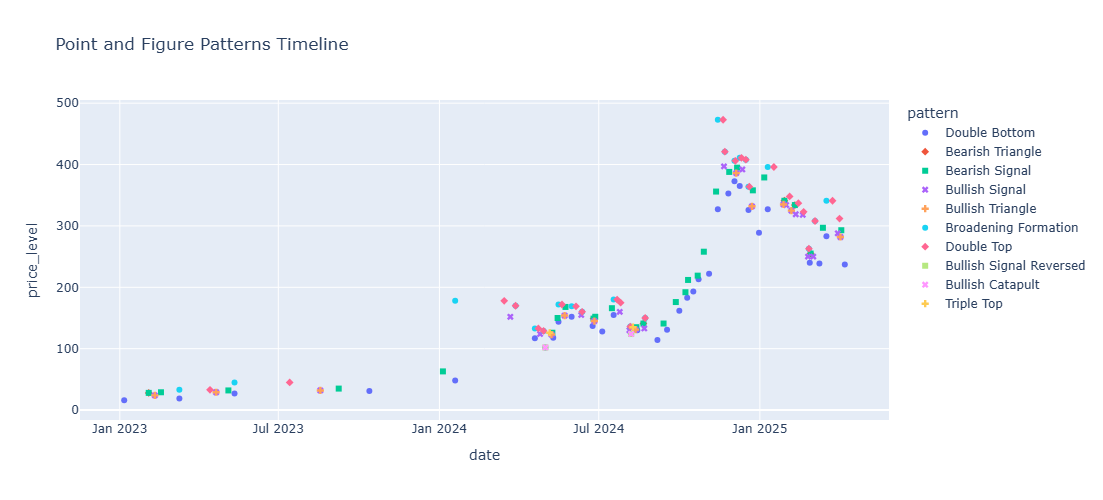

In [117]:
df_patterns = pd.DataFrame(all_patterns)
df_patterns['date'] = pd.to_datetime(df_patterns['date'])
df_patterns = df_patterns.sort_values('date', ascending=True)
df_pnfcolumns = pd.DataFrame(pnf_columns)
# Group and count patterns by date
df_pattern_counts = df_patterns['date'].value_counts().sort_index()
#df_strategicpositions = pd.DataFrame(strategic_positions)

# Extract unique sorted monthly tick positions
monthly_ticks = pd.date_range(start=df_patterns['date'].min(), end=df_patterns['date'].max(), freq='MS')  # 'MS' = Month Start
tickvals = monthly_ticks
ticktext = monthly_ticks.strftime('%b %Y')

# Plot Patterns
fig_patterns = px.scatter(df_patterns, x='date', y='price_level',
                 color='pattern',
                 symbol='pattern',
                 title="P&F Patterns Timeline",
                 labels={'breakout_price': 'Price Level'})
fig_patterns.update_traces(marker=dict(size=6))
fig_patterns.update_layout(height=500, width=1000, title_text="Point and Figure Patterns Timeline")
fig_patterns.show()

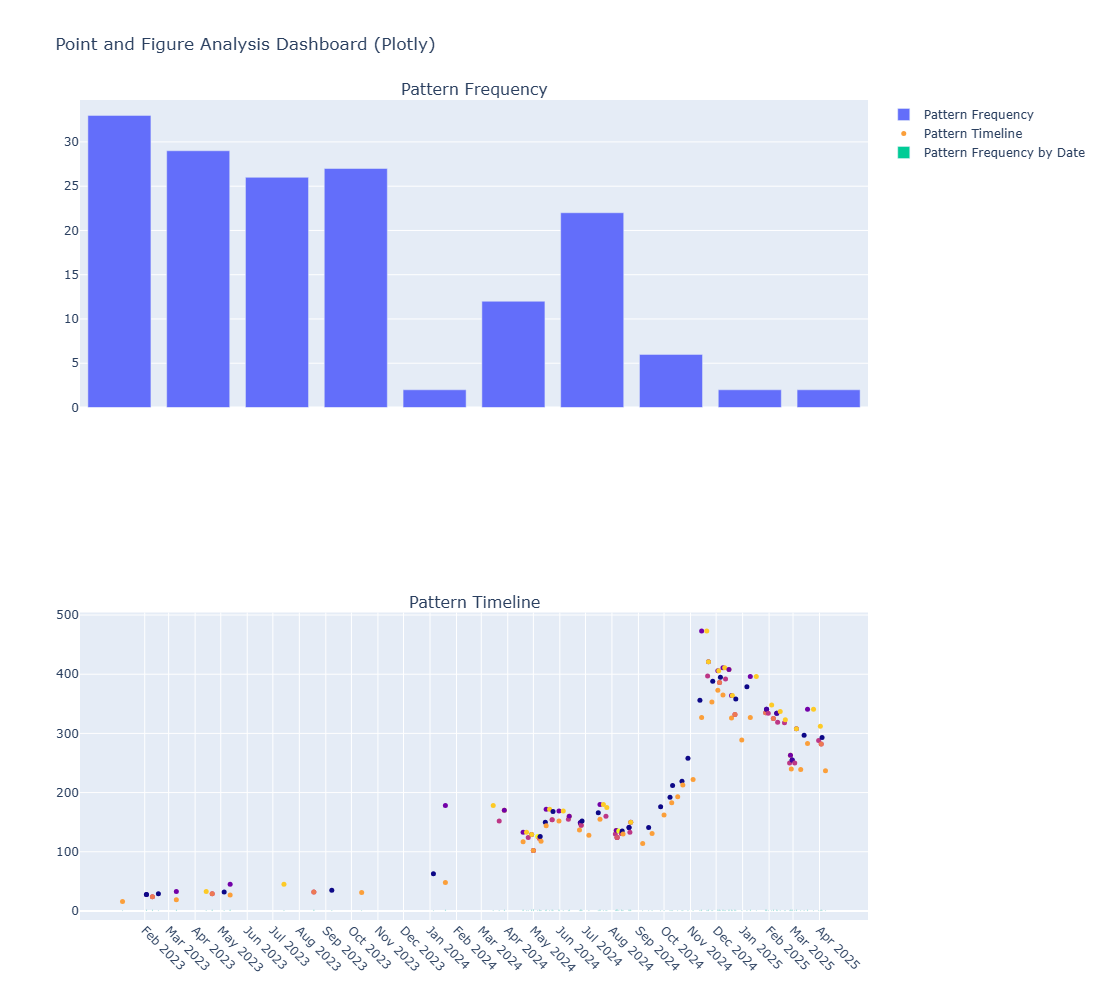

In [118]:
# Re-run the Plotly subplot section now that `make_subplots` is imported
fig_plotly = make_subplots(rows=2, cols=1, subplot_titles=(
    "Pattern Frequency",
    "Pattern Timeline",
    "Aggregated Pattern Count",
    "Trading Signals"
))

# 1. Pattern Frequency Bar
fig_plotly.add_trace(go.Bar(
    x=list(pattern_counts.keys()),
    y=list(pattern_counts.values()),
    name="Pattern Frequency"
), row=1, col=1)

# 2. Pattern Timeline
fig_plotly.add_trace(go.Scatter(
    x=df_patterns['date'],
    y=df_patterns['price_level'],
    mode='markers',
    marker=dict(size=5, color=df_patterns['pattern'].astype('category').cat.codes),
    text=df_patterns['pattern'],
    name="Pattern Timeline"
), row=2, col=1)

# 3. Aggregated Pattern Count by Date
fig_plotly.add_trace(go.Bar(
    x=df_pattern_counts.index,
    y=df_pattern_counts.values,
    name="Pattern Frequency by Date"
), row=2, col=1)

# 4. Trading Signal Visualization
#fig_plotly.add_trace(go.Scatter(
#    x=df_strategicpositions['date'],
#    y=df_strategicpositions['price'],
#    mode='markers+text',
#    marker=dict(color=['green' if t == 'BUY' else 'red' for t in strategy_df['type']], size=6),
#    text=df_strategicpositions['type'],
#    name="Trade Signals"
#), row=2, col=2)

# Apply the monthly gridlines to all subplots
fig_plotly.update_xaxes(
    tickvals=tickvals,  # Set the tick values (monthly)
    ticktext=ticktext,  # Set the tick text (formatted dates)
    showgrid=True,      # Show gridlines
    tickangle=45        # Rotate tick labels if necessary
)

fig_plotly.update_yaxes(
    showgrid=True  # Apply gridlines on y-axes for all subplots
)

fig_plotly.update_layout(height=1000, width=1000, title_text="Point and Figure Analysis Dashboard (Plotly)")
fig_plotly.show()

In addition to using the **Point and Figure (P&F)** charting method to track price movements and identify key price patterns (like breakouts, reversals, and trend lines), a professional trader might integrate several advanced strategies and techniques to maximize their trading decisions. Here are a few approaches a professional trader might take with P&F charts:

### 1. **Trendline Analysis**
   - **Identify Trend Reversals and Breakouts:**
     - Trendlines like **bullish support** and **bearish resistance** can help identify key price levels where the trend might reverse or continue. A trader would watch for breakouts above resistance or breakdowns below support, as these signals could indicate strong price moves.
   - **Support and Resistance Zones:**
     - P&F charts excel at identifying horizontal support and resistance zones. Professional traders often monitor price action near these zones to anticipate potential reversals or the likelihood of price continuation.

### 2. **Pattern Recognition and Price Objectives**
   - **Price Objectives with Vertical Counts:**
     - **Vertical count** is a method used to predict the potential price target after a breakout. By counting the number of boxes between the breakout level and the next column, traders can forecast price objectives for both bullish and bearish trends.
     - **Horizontal count** patterns, used in conjunction with price objectives, provide insights into potential price targets after a consolidation or breakout pattern.

### 3. **Volume Analysis**
   - **Volume-based Confirmation:**
     - Volume analysis is critical for confirming P&F signals. A professional trader would look for spikes in volume to confirm that breakouts or reversals are genuine and not false signals. Volume could act as a secondary indicator to validate the price movement.
   - **Volume Analysis During Pattern Formation:**
     - Traders may also monitor volume as the chart forms patterns (like a double top, triple top, or breakout pattern) to validate the strength of the pattern.

### 4. **Risk Management and Position Sizing**
   - **Stop-Loss and Take-Profit Levels:**
     - With P&F charts, traders often set tight stop-losses based on recent support/resistance levels identified in the chart. They may also place take-profit targets based on price objectives or trendline breaks.
   - **Position Sizing:**
     - Professional traders use risk-reward ratios when setting trades. They ensure that their risk on each trade does not exceed a certain percentage of their capital, adjusting position sizes based on the confidence level of the P&F signals.

### 5. **Multiple Timeframes**
   - **Cross-Timeframe Analysis:**
     - Professional traders often combine P&F charts on multiple timeframes (e.g., daily, weekly, and monthly charts) to get a broader view of the market. This helps identify long-term trends and short-term entry points.
   - **Intraday Trading:**
     - For day traders or intraday traders, P&F charts can be used in very short timeframes (like 1-minute or 5-minute charts) to catch quick movements based on real-time patterns.

### 6. **Integration with Other Charting Methods**
   - **Combining with Other Technical Indicators:**
     - P&F charting is often used alongside other technical indicators, such as **Moving Averages (MA)**, **Relative Strength Index (RSI)**, **Bollinger Bands**, or **MACD** to confirm trends and refine entry and exit signals.
   - **Candlestick Patterns and Price Action:**
     - Traders may also overlay candlestick patterns or use price action analysis to corroborate P&F signals and gain further confidence in their trades.

### 7. **Backtesting and Automation**
   - **Backtesting Strategies:**
     - Professional traders use backtesting to evaluate the effectiveness of their P&F-based strategies across different market conditions. They can automate the strategy to test its profitability, win rate, and drawdowns using historical price data.
   - **Automated Trading Systems:**
     - Some traders may automate their P&F-based trading strategies to execute trades automatically once a valid signal is generated. These systems can execute trades with speed and accuracy, removing human error and emotional bias.

### 8. **Pattern and Box Size Adjustment**
   - **Dynamic Box Size:**
     - Some traders adjust the box size and reversal criteria dynamically based on the volatility of the market. They may use smaller box sizes during high volatility periods to capture more granular price movements, or larger box sizes in low volatility environments for a more stable view of trends.
   - **Reversal Criteria Adjustment:**
     - Reversal criteria (usually 3-box or 5-box reversal) can be adjusted to fine-tune the sensitivity of the chart. Traders may experiment with different reversal settings to match their trading style.

### 9. **Trade Journal and Performance Tracking**
   - **Trade Log Analysis:**
     - A key practice of professional traders is to maintain a detailed trade journal. This includes not just the outcome (profit/loss) but the reasoning behind each trade (based on P&F patterns and objectives), which helps in refining strategies and learning from mistakes.
   - **Performance Review:**
     - After a series of trades, traders review the overall performance, analyze the effectiveness of the P&F signals, and adjust their strategy accordingly.

### 10. **Market Sentiment Analysis**
   - **Psychological Patterns and Market Behavior:**
     - Professional traders often combine P&F with market sentiment indicators to assess the overall mood of the market. A pattern like a **triple top** might indicate a bearish sentiment shift, while a **bullish breakout** could align with growing market optimism.

---

### Conclusion

For professional traders, **Point and Figure charts** are not standalone tools but part of a broader toolkit used to track, anticipate, and react to market conditions. A disciplined approach involves leveraging **P&F charts for clear, noise-free trend analysis**, combining them with **advanced pattern recognition**, **volume analysis**, **risk management strategies**, and **market sentiment** for a comprehensive view of the market. By combining these elements, a trader can create more robust trading strategies that adapt to various market conditions.